In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../notebooks/DATA/iris.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<Axes: xlabel='species', ylabel='count'>

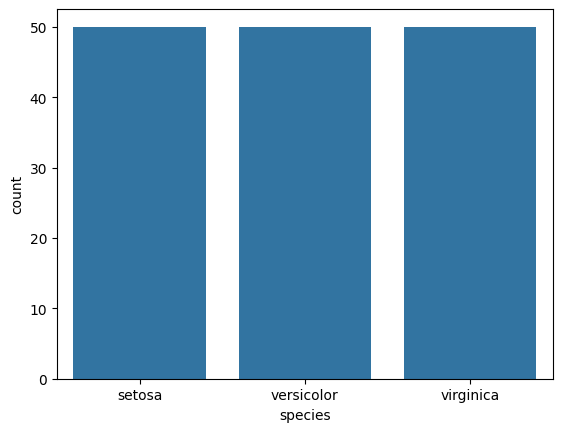

In [6]:
sns.countplot(x='species', data=df)

<Axes: xlabel='petal_length', ylabel='petal_width'>

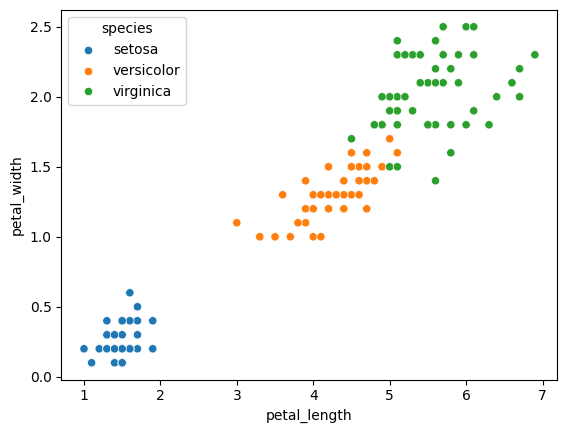

In [7]:
sns.scatterplot(x='petal_length', y='petal_width', data=df, hue='species')

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

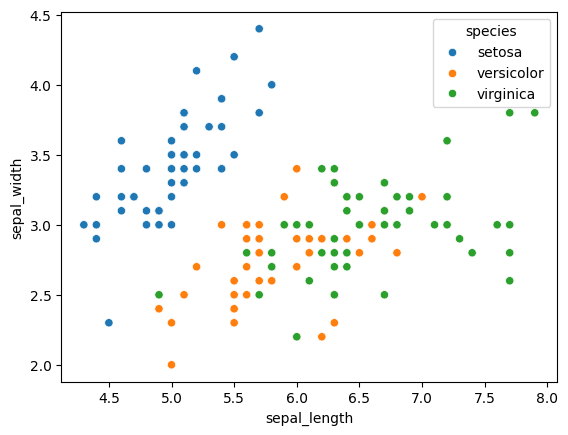

In [8]:
sns.scatterplot(x='sepal_length', y='sepal_width', data=df, hue='species')

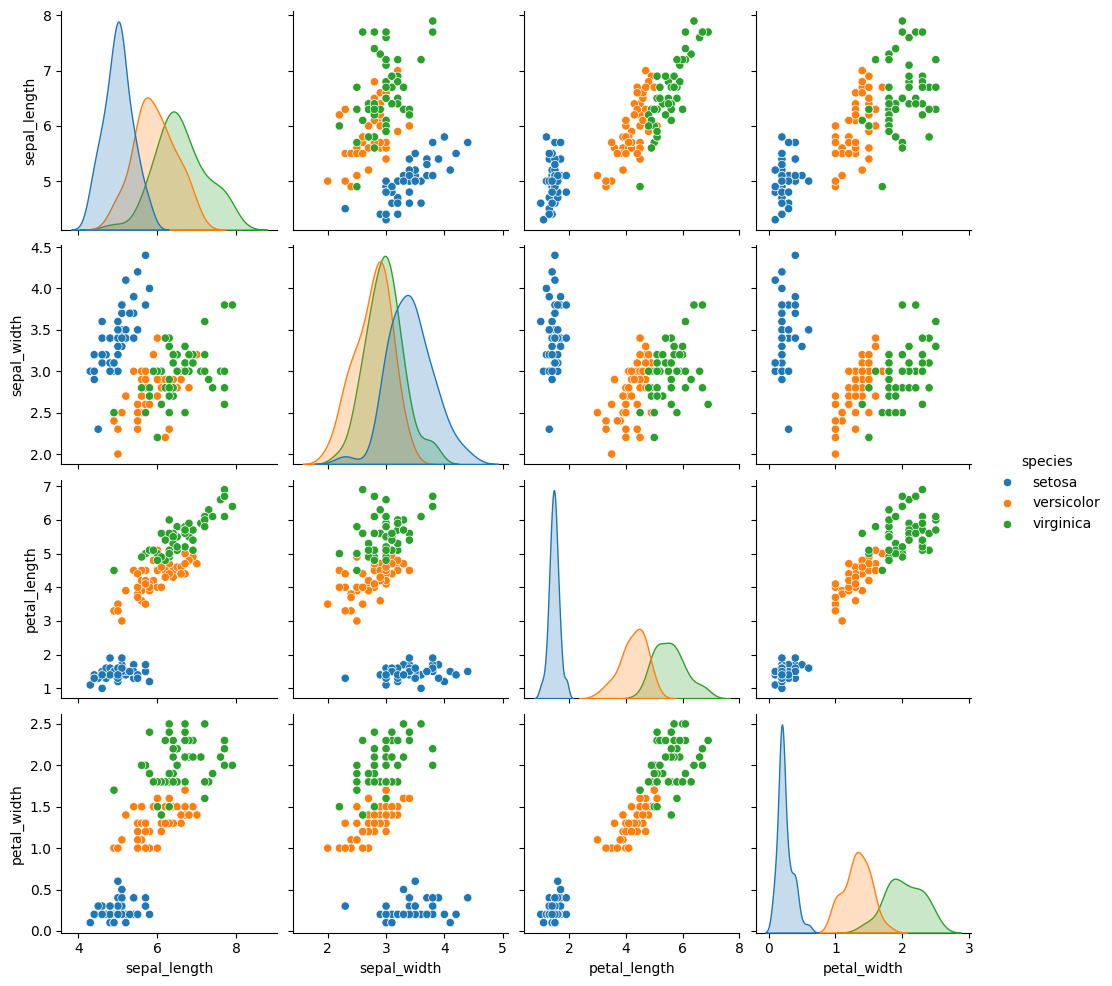

In [9]:
sns.pairplot(data=df, hue='species')

<Axes: >

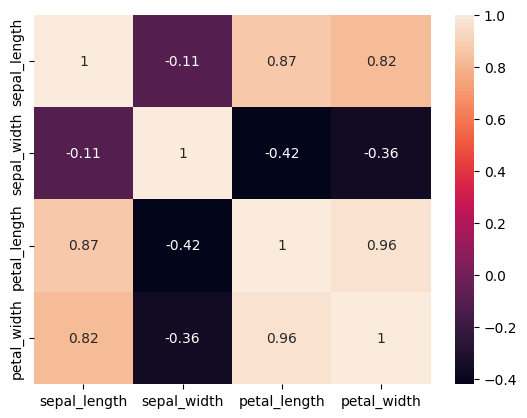

In [10]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

In [11]:
X = df.drop('species', axis=1)
y = df['species']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.22, random_state=42)

In [15]:
scaler = StandardScaler()

In [16]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier

In [19]:
log_model = LogisticRegression(solver='saga', max_iter=5000)
log_model = OneVsRestClassifier(log_model)

In [20]:
penalty = ['l1', 'l2', 'elastic_net']
l1_ratio = np.linspace(0,1,20)
C = np.logspace(0,10,20)

param_grid = {'estimator__penalty': penalty,
              'estimator__l1_ratio': l1_ratio,
              'estimator__C': C}

In [21]:
grid_model = GridSearchCV(log_model, param_grid=param_grid)

In [ ]:
grid_model.fit(scaled_X_train, y_train)

In [24]:
y_pred = grid_model.best_params_
y_pred

{'estimator__C': np.float64(37.926901907322495),
 'estimator__l1_ratio': np.float64(0.0),
 'estimator__penalty': 'l2'}

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [26]:
y_pred = grid_model.predict(scaled_X_test)

In [27]:
accuracy_score(y_test, y_pred)

1.0

In [28]:
confusion_matrix(y_test, y_pred)

array([[12,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 11]])

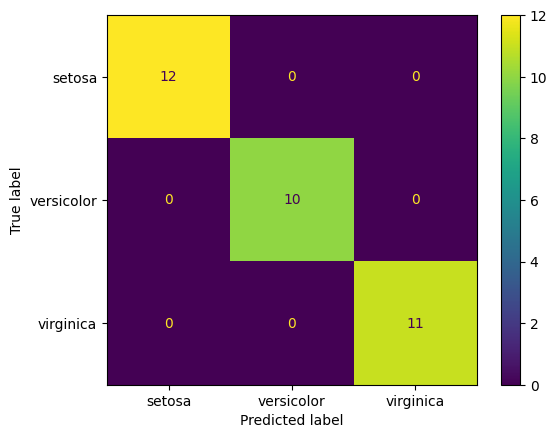

In [29]:
ConfusionMatrixDisplay.from_estimator(grid_model, scaled_X_test, y_test)

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



In [33]:
from sklearn.metrics import  roc_curve, auc

In [45]:
def plot_multicalss_roc(clf, X_test, y_test, n_classes, figsize=(5,5)):
    y_score = clf.decision_function(X_test)

    fpr = {}
    tpr = {}
    roc_auc = {}

    y_test_dummies = pd.get_dummies(y_test, drop_first=False).values

    # compute ROC metrics
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_dummies[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # create plot
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot([0,1], [0,1], 'k--')
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)

    # plot ROC curves
    for i in range(n_classes):
        ax.plot(fpr[i], tpr[i], label=f'ROC curve (area = {roc_auc[i]:.2f} for label {i})')

    ax.legend(loc="best")
    ax.grid(alpha=0.4)
    sns.despine()

    plt.show()

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


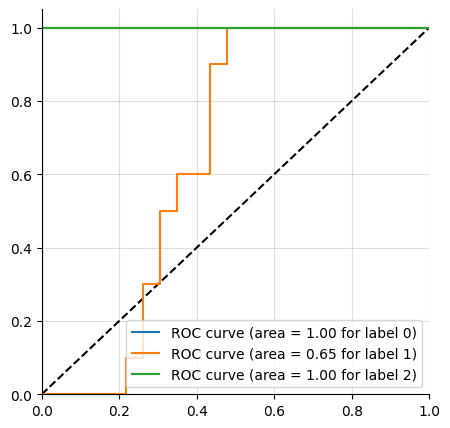

In [46]:
plot_multicalss_roc(grid_model, X_test, y_test, 3, figsize=(5,5))